<a href="https://colab.research.google.com/github/beenishtech/MY-DEEP-LEARNING-PROJECT-classify-images-./blob/main/Classify_images_cats_and_dogs_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries Import

In [78]:
import os #To handle folders, directories, and file paths/Tells the code where to find files and folders (Provides file paths)
import tensorflow as tf #The main Deep Learning library to build and train models
from tensorflow.keras import layers, models # Tools to create different layers (like CNN) and structure the model
import matplotlib.pyplot as plt # Used to plot graphs and display images
import numpy as np ## Used for fast mathematical operations and handling data arrays
from tensorflow.keras.preprocessing import image # Tool to easily load and resize images for the model
import cv2  # OpenCV library used for advanced image processing and modification



#Unziping file

In [73]:
!unzip -q "archive (2).zip"  #Unziping file (without-q it shows long unziped file output)

replace cats_set/cat.4001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [79]:
# Check number of images in folders/ check if file zip or unzip if number show it mean file is unzip.
print("Total Cats:", len(os.listdir("cats_set")))
print("Total Dogs:", len(os.listdir("dogs_set")))

Total Cats: 500
Total Dogs: 500


#CNN Model Design and Training Pipeline

In [86]:
data_dir = "/content" #set path Folder where your data is saved

#Data load and split in Train/Validation
img_size = (150, 150) # Sets standard size for all images
batch_size = 32 # Process 32 images at a single time

# Training Data (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, # Look for images inside /content folder
    validation_split=0.2, # Keep 20% data separate for testing
    subset="training", # Use the remaining 80% data for training
    seed=123, # Keeps the data split same every time you run
    image_size=img_size,  # Resize all images to 150x150
    batch_size=batch_size, # Group images into batches of 32
    class_names=['cats_set', 'dogs_set'] # Names of our two image folders
)

# Validation Data (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation", # Use this 20% data to test the model
    seed=123,            # Keeps the data split same every time you run
    image_size=img_size,
    batch_size=batch_size,
    class_names=['cats_set', 'dogs_set']
)

#Speed Optimization Code (AUTOTUNE)
AUTOTUNE = tf.data.AUTOTUNE # Automatically handles computer memory speed

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) # Loads data faster and mixes it up
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE) # Loads test data faster without mixing

# Model Architecture
model = models.Sequential([ # Creates a step-by-step layer chain
    layers.Input(shape=(150, 150, 3)), # Defines input image size and color channels (RGB)

    layers.Rescaling(1./255), # Changes pixel values from 0-255 to 0-1 for fast learning

    layers.Conv2D(32, (3, 3), activation='relu'), # Finds basic shapes like edges/lines in image
    layers.MaxPooling2D((2, 2)), # Reduces image size to focus on main details

    layers.Conv2D(64, (3, 3), activation='relu'),# Finds medium shapes like eyes/ears
    layers.MaxPooling2D((2, 2)), # Reduces image size again

    layers.Conv2D(128, (3, 3), activation='relu'), # Finds complex shapes like full face
    layers.MaxPooling2D((2, 2)), # Reduces size one last time

    layers.Flatten(), ## Converts 2D image matrix into a single 1D line
    layers.Dense(128, activation='relu'), # Brain layer that connects features to understand patterns
    layers.Dense(1, activation='sigmoid') # Final output layer (Outputs 0 for Cat, 1 for Dog)
])

# Model Compile
model.compile(
    optimizer='adam',  # Smart algorithm to auto-correct model mistakes
    loss='binary_crossentropy', # Math formula to calculate errors for 2 choices
    metrics=['accuracy'] # Shows the model's correct guess percentage
)

model.summary() # Prints the complete blueprint/structure of model

# Model Train
history = model.fit(
    train_ds, # Give training data to the model
    validation_data=val_ds, # Give test data to check model performance
    epochs=10 # Repeat the whole training process 10 times
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.4837 - loss: 0.7388 - val_accuracy: 0.5650 - val_loss: 0.6920
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.5188 - loss: 0.6919 - val_accuracy: 0.5800 - val_loss: 0.6821
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6062 - loss: 0.6664 - val_accuracy: 0.5950 - val_loss: 0.6631
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6637 - loss: 0.6183 - val_accuracy: 0.6300 - val_loss: 0.6924
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7125 - loss: 0.5908 - val_accuracy: 0.6250 - val_loss: 0.6492
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7437 - loss: 0.5078 - val_accuracy: 0.6500 - val_loss: 0.7298
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7800 - loss: 0.4401 - val_accuracy: 0.6950 - val_loss: 0.6175
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8150 - loss: 0.3961 - val_accuracy: 0.6800 - val_loss:

#Model Testing/ Predict and Visualize Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


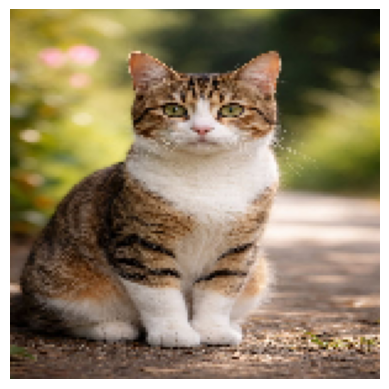


--- RESULT ---
I am 70.44% sure it is a CAT


In [87]:
# Defines a custom function to test any new image
def classify_image(image_name):
    img_path = f'/content/{image_name}' # Joins the folder path with your image name

    # Image loading aur preprocessing
    img = image.load_img(img_path, target_size=(150, 150)) # Loads image and resizes it to 150x150
    img_array = image.img_to_array(img) # Converts the image into a numpy numbers array
    img_array = tf.expand_dims(img_array, 0) # Adds an extra dimension to represent batch size (1 image)

    # Prediction
    predictions = model.predict(img_array) # Asks the trained model to guess the image
    score = predictions[0][0] # Extracts the raw prediction percentage score

    # visualization
    plt.imshow(img) # Prepares the image to be displayed on screen
    plt.axis('off') # Hides the graph graph lines and numbers around image
    plt.show() # Finally displays the image in output

    print("\n--- RESULT ---")
    if score > 0.5: # If score is greater than 0.5, it's a dog
        print(f"I am {100 * score:.2f}% sure it is a DOG")
    else: # If score is 0.5 or less, it's a cat
        print(f"I am {100 * (1 - score):.2f}% sure it is a CAT")


# function call
classify_image('my_test_image.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


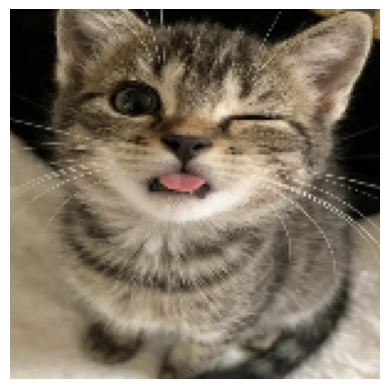


--- RESULT ---
I am 68.50% sure it is a CAT


In [88]:
classify_image ('my_test_image2.jpg') #Functoion call

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


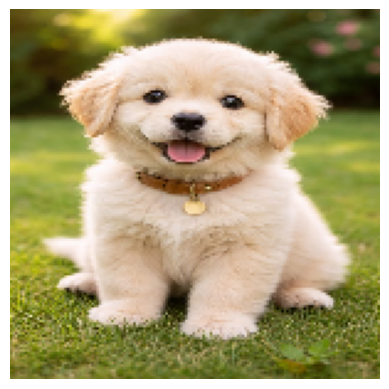


--- RESULT ---
I am 99.95% sure it is a DOG


In [89]:
classify_image ('my_test_image3.jpg') #function call